In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alistairking/weather-long-term-time-series-forecasting/cleaned_weather.csv


In [4]:
import warnings

warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.*")

In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/alistairking/weather-long-term-time-series-forecasting/cleaned_weather.csv")
df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


['/kaggle/input/datasets/alistairking/weather-long-term-time-series-forecasting/cleaned_weather.csv']
Klausimas 1
Nuo: 2020-01-01 00:10:00
Iki: 2021-01-01 00:00:00
Intervalas minutėmis: 10.0
Vidutinė temperatūra: 10.8
Minimali temperatūra: -6.4
Maksimali temperatūra: 34.8

Klausimas 2
      mean  min   max
date                 
3      5.4 -5.7  17.6
4     10.4 -6.4  22.8
5     11.9 -2.1  24.1

2020 mėnesių vidutinė ir maksimali temperatūra
      mean_temp  max_temp
date                     
1           3.5      14.0
2           5.8      17.2
3           5.4      17.6
4          10.4      22.8
5          11.9      24.1
6          17.4      29.4
7          19.0      28.6
8          20.8      34.8
9          15.4      30.2
10         10.9      20.6
11          6.2      20.0
12          3.3      14.5


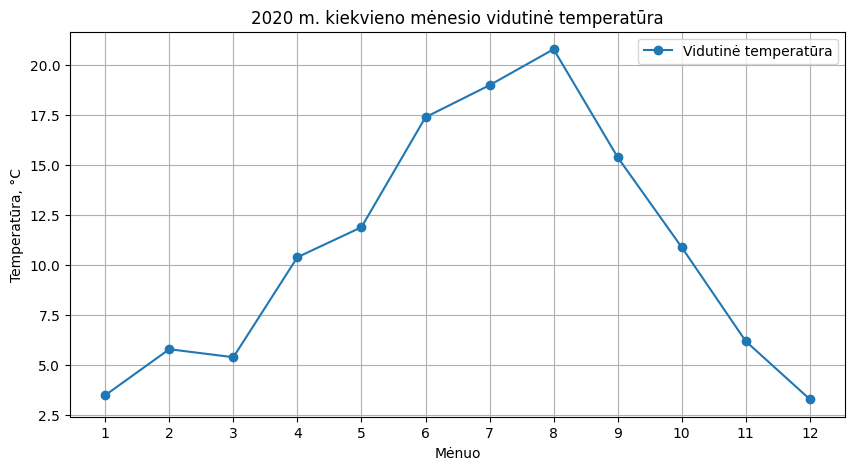

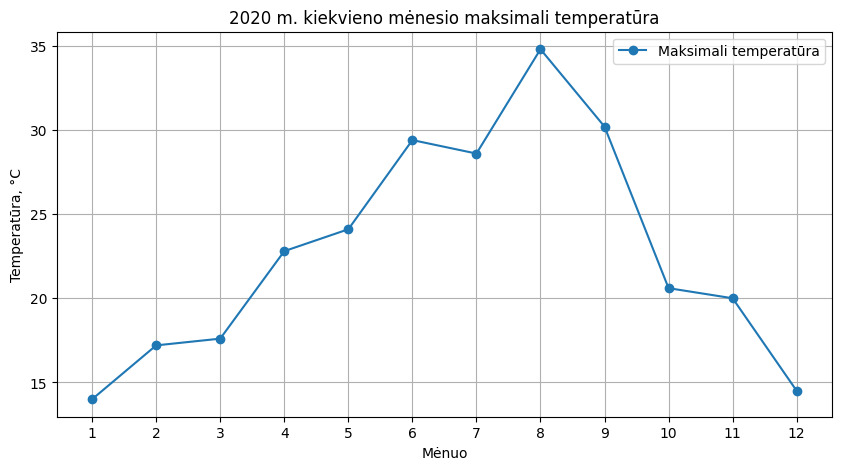

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

paths = glob.glob("/kaggle/input/**/cleaned_weather.csv", recursive=True)
print(paths)

df = pd.read_csv(paths[0])

# Datos konvertavimas
df["date"] = pd.to_datetime(df["date"])

# Klausimas 1
start_date = df["date"].min()
end_date = df["date"].max()

interval_minutes = (
    df["date"]
    .sort_values()
    .diff()
    .dropna()
    .dt.total_seconds()
    .div(60)
    .mode()[0]
)

avg_temp = df["T"].mean()
min_temp = df["T"].min()
max_temp = df["T"].max()

print("Klausimas 1")
print("Nuo:", start_date)
print("Iki:", end_date)
print("Intervalas minutėmis:", interval_minutes)
print("Vidutinė temperatūra:", round(avg_temp, 1))
print("Minimali temperatūra:", round(min_temp, 1))
print("Maksimali temperatūra:", round(max_temp, 1))

# Tik 2020 metų duomenys
df_2020 = df[df["date"].dt.year == 2020].copy()

# Klausimas 2
monthly_stats = (
    df_2020
    .groupby(df_2020["date"].dt.month)["T"]
    .agg(["mean", "min", "max"])
    .round(1)
)

print("\nKlausimas 2")
print(monthly_stats.loc[[3, 4, 5]])

# Klausimas 4
monthly_2020 = (
    df_2020
    .groupby(df_2020["date"].dt.month)["T"]
    .agg(mean_temp="mean", max_temp="max")
    .round(1)
)

print("\n2020 mėnesių vidutinė ir maksimali temperatūra")
print(monthly_2020)

# Grafikas: vidutinė temperatūra
plt.figure(figsize=(10, 5))
plt.plot(monthly_2020.index, monthly_2020["mean_temp"], marker="o", label="Vidutinė temperatūra")
plt.xticks(range(1, 13))
plt.xlabel("Mėnuo")
plt.ylabel("Temperatūra, °C")
plt.title("2020 m. kiekvieno mėnesio vidutinė temperatūra")
plt.legend()
plt.grid(True)
plt.show()

# Grafikas: maksimali temperatūra
plt.figure(figsize=(10, 5))
plt.plot(monthly_2020.index, monthly_2020["max_temp"], marker="o", label="Maksimali temperatūra")
plt.xticks(range(1, 13))
plt.xlabel("Mėnuo")
plt.ylabel("Temperatūra, °C")
plt.title("2020 m. kiekvieno mėnesio maksimali temperatūra")
plt.legend()
plt.grid(True)
plt.show()

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
26/04/30 12:42:12 WARN DAGScheduler: Failed to cancel job group 1c32c7fc-0b21-465d-b6a9-16d27b096bca. Cannot find active jobs for it.


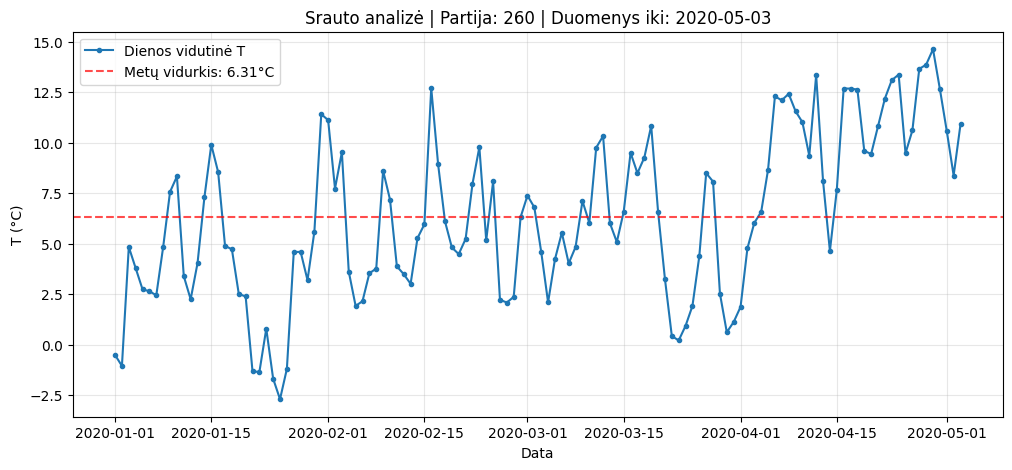

--- STATISTIKA TIES PARTIJA 260 (Tik pilnos dienos) ---
🌍 BENDRA (nuo sausio): Min: -2.71°C | Max: 14.63°C | Vid: 6.31°C
📅 MAY (iki 3 d.): Min: 8.37°C | Max: 10.91°C | Vid: 9.96°C

Srautas sustabdytas.


26/04/30 12:42:15 WARN DAGScheduler: Failed to cancel job group 1c32c7fc-0b21-465d-b6a9-16d27b096bca. Cannot find active jobs for it.


In [10]:
import time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("WeatherStreaming").getOrCreate()

raw_path = "/kaggle/input/datasets/alistairking/weather-long-term-time-series-forecasting/cleaned_weather.csv"
raw_df = spark.read.csv(raw_path, header=True, inferSchema=True).select("date", "T")

# Surūšiuojame ir suteikiame indeksą srautui (kad eitų chronologiškai)
windowSpec = Window.orderBy("date")
static_indexed = raw_df.withColumn("idx", F.row_number().over(windowSpec) - 1).cache()

# Kaupikliai grafikui ir statistikai
time_data = []
temp_data = []

def process_batch(batch_df, batch_id):
    pdf = batch_df.toPandas()

    if not pdf.empty:
        pdf["date"] = pd.to_datetime(pdf["date"])

        time_data.extend(pdf["date"].tolist())
        temp_data.extend(pdf["T"].tolist())

        full_df = pd.DataFrame({
            "date": pd.to_datetime(time_data),
            "T": temp_data
        })

        daily_stats = full_df.groupby(full_df["date"].dt.date)["T"].mean().reset_index()
        daily_stats.columns = ["date", "T"]
        daily_stats["date"] = pd.to_datetime(daily_stats["date"])

        max_date = daily_stats["date"].max()
        plot_df = daily_stats[daily_stats["date"] < max_date]

        if plot_df.empty:
            return

        current_all_avg = plot_df["T"].mean()
        current_min = plot_df["T"].min()
        current_max = plot_df["T"].max()

        last_completed_date = plot_df["date"].iloc[-1]
        curr_month = last_completed_date.month
        month_name = last_completed_date.strftime("%B")

        m_df = plot_df[plot_df["date"].dt.month == curr_month]
        m_avg = m_df["T"].mean()
        m_min = m_df["T"].min()
        m_max = m_df["T"].max()

        clear_output(wait=True)

        plt.figure(figsize=(12, 5))
        plt.plot(
            plot_df["date"],
            plot_df["T"],
            color="tab:blue",
            marker="o",
            markersize=3,
            linewidth=1.5,
            label="Dienos vidutinė T"
        )

        plt.axhline(
            y=current_all_avg,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"Metų vidurkis: {current_all_avg:.2f}°C"
        )

        plt.title(f"Srauto analizė | Partija: {batch_id} | Duomenys iki: {last_completed_date.date()}")
        plt.xlabel("Data")
        plt.ylabel("T (°C)")
        plt.legend(loc="upper left")
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"--- STATISTIKA TIES PARTIJA {batch_id} (Tik pilnos dienos) ---")
        print(f"🌍 BENDRA (nuo sausio): Min: {current_min:.2f}°C | Max: {current_max:.2f}°C | Vid: {current_all_avg:.2f}°C")
        print(f"📅 {month_name.upper()} (iki {last_completed_date.day} d.): Min: {m_min:.2f}°C | Max: {m_max:.2f}°C | Vid: {m_avg:.2f}°C")

        time.sleep(3)

# SRAUTO KONFIGŪRAVIMAS
rate_df = spark.readStream.format("rate").option("rowsPerSecond", 20).load()

stream_df = rate_df.selectExpr("value as idx").join(static_indexed, on="idx")

# PALEIDIMAS
query = stream_df.writeStream.foreachBatch(process_batch).start()

try:
    query.awaitTermination()
except KeyboardInterrupt:
    query.stop()
    print("\nSrautas sustabdytas.")

Naudojamas failas: /kaggle/input/datasets/alistairking/weather-long-term-time-series-forecasting/cleaned_weather.csv


,Mėnuo,Mėnesio 1-13 d. vid. T,Mėnesio 1-13 d. min. T,Mėnesio 1-13 d. max. T,Nuo metų pradžios iki 13 d. vid. T,Nuo metų pradžios iki 13 d. min. T,Nuo metų pradžios iki 13 d. max. T
0,Sausis,3.5,-1.1,8.3,3.5,-1.1,8.3
1,Vasaris,5.3,1.9,11.1,4.0,-2.7,11.4
2,Kovas,6.1,2.1,10.3,4.8,-2.7,12.7
3,Balandis,9.1,1.9,13.3,5.4,-2.7,13.3
4,Gegužė,10.0,5.2,15.5,6.6,-2.7,15.5
5,Birželis,15.3,11.6,22.2,8.0,-2.7,22.2
6,Liepa,18.2,13.7,22.4,9.6,-2.7,22.4
7,Rugpjūtis,22.4,17.1,26.9,11.2,-2.7,26.9
8,Rugsėjis,16.3,13.1,20.4,12.0,-2.7,26.9
9,Spalis,11.2,6.4,15.3,12.1,-2.7,26.9


Lentelė išsaugota: /kaggle/working/temperaturos_lentele_13_dienu.csv


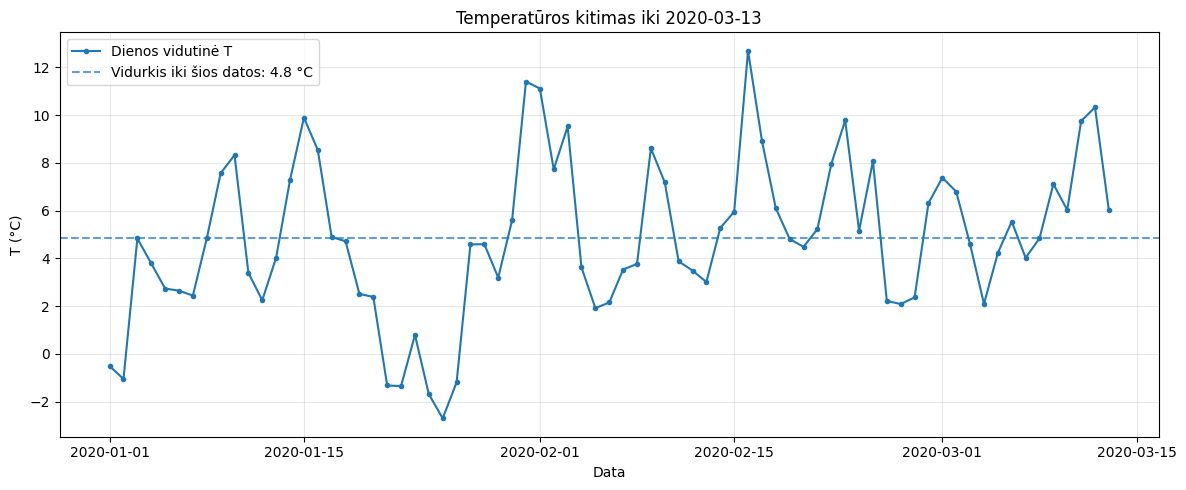

Grafikas išsaugotas: /kaggle/working/kovo_13_temperaturos_grafikas.png


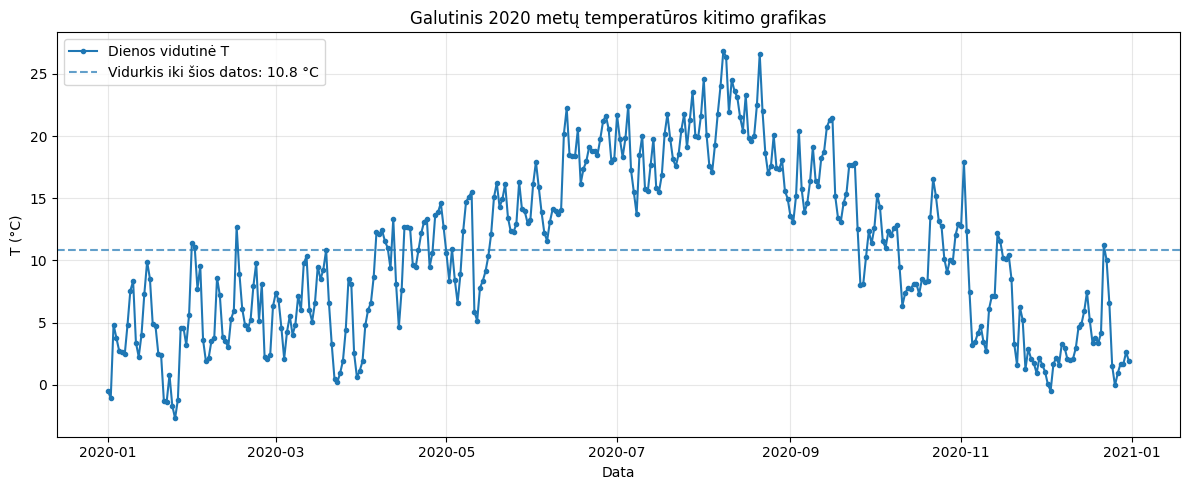

Grafikas išsaugotas: /kaggle/working/galutinis_visu_metu_temperaturos_grafikas.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# 1. Surandam failą Kaggle aplinkoje
paths = glob.glob("/kaggle/input/**/cleaned_weather.csv", recursive=True)

if len(paths) == 0:
    raise FileNotFoundError("Neradau cleaned_weather.csv. Patikrink Kaggle input kelią.")

raw_path = paths[0]
print("Naudojamas failas:", raw_path)

# 2. Nuskaitom duomenis
df = pd.read_csv(raw_path, usecols=["date", "T"])
df["date"] = pd.to_datetime(df["date"])

# Paliekam tik 2020 metus
df_2020 = df[df["date"].dt.year == 2020].copy()

# 3. Atkartojam ankstesnio streaming kodo logiką:
# pirmiausia skaičiuojama kiekvienos dienos vidutinė temperatūra
daily_stats = (
    df_2020
    .groupby(df_2020["date"].dt.date)["T"]
    .mean()
    .reset_index()
)

daily_stats.columns = ["date", "T"]
daily_stats["date"] = pd.to_datetime(daily_stats["date"])

# 4. Lentelė kiekvieno mėnesio pirmoms 13 dienų
month_names_lt = {
    1: "Sausis",
    2: "Vasaris",
    3: "Kovas",
    4: "Balandis",
    5: "Gegužė",
    6: "Birželis",
    7: "Liepa",
    8: "Rugpjūtis",
    9: "Rugsėjis",
    10: "Spalis",
    11: "Lapkritis",
    12: "Gruodis"
}

rows = []

for month in range(1, 13):
    cutoff_date = pd.Timestamp(year=2020, month=month, day=13)

    # To mėnesio pirmos 13 dienų
    month_13 = daily_stats[
        (daily_stats["date"].dt.month == month) &
        (daily_stats["date"].dt.day <= 13)
    ]

    # Nuo metų pradžios iki to mėnesio 13 dienos imtinai
    cumulative_13 = daily_stats[
        (daily_stats["date"] >= pd.Timestamp("2020-01-01")) &
        (daily_stats["date"] <= cutoff_date)
    ]

    rows.append({
        "Mėnuo": month_names_lt[month],

        "Mėnesio 1-13 d. vid. T": month_13["T"].mean(),
        "Mėnesio 1-13 d. min. T": month_13["T"].min(),
        "Mėnesio 1-13 d. max. T": month_13["T"].max(),

        "Nuo metų pradžios iki 13 d. vid. T": cumulative_13["T"].mean(),
        "Nuo metų pradžios iki 13 d. min. T": cumulative_13["T"].min(),
        "Nuo metų pradžios iki 13 d. max. T": cumulative_13["T"].max()
    })

result_table = pd.DataFrame(rows)

# Apvalinam iki 1 skaitmens po kablelio, kaip prašo užduotis
numeric_cols = result_table.columns.drop("Mėnuo")
result_table[numeric_cols] = result_table[numeric_cols].round(1)

display(result_table)

# Išsaugom lentelę, jeigu reikės įkelti / pasižiūrėti
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

table_path = f"{output_dir}/temperaturos_lentele_13_dienu.csv"
result_table.to_csv(table_path, index=False, encoding="utf-8-sig")

print("Lentelė išsaugota:", table_path)


# 5. Funkcija grafikams
def plot_temperature_until(cutoff_date, filename, title_suffix):
    plot_df = daily_stats[daily_stats["date"] <= cutoff_date].copy()

    current_all_avg = plot_df["T"].mean()

    plt.figure(figsize=(12, 5))
    plt.plot(
        plot_df["date"],
        plot_df["T"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Dienos vidutinė T"
    )

    plt.axhline(
        y=current_all_avg,
        linestyle="--",
        alpha=0.7,
        label=f"Vidurkis iki šios datos: {current_all_avg:.1f} °C"
    )

    plt.title(title_suffix)
    plt.xlabel("Data")
    plt.ylabel("T (°C)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{output_dir}/{filename}"
    plt.savefig(save_path, dpi=150)
    plt.show()

    print("Grafikas išsaugotas:", save_path)


# 6. Kovo 13 d. grafikas
plot_temperature_until(
    cutoff_date=pd.Timestamp("2020-03-13"),
    filename="kovo_13_temperaturos_grafikas.png",
    title_suffix="Temperatūros kitimas iki 2020-03-13"
)

# 7. Galutinis visų metų grafikas
plot_temperature_until(
    cutoff_date=pd.Timestamp("2020-12-31"),
    filename="galutinis_visu_metu_temperaturos_grafikas.png",
    title_suffix="Galutinis 2020 metų temperatūros kitimo grafikas"
)